<a href="https://colab.research.google.com/github/enicaking/ml-applications-project-repo/blob/main/notebooks/02_task1_nlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2. Task 1: Text preprocessing & vectorization

We build 4 vectorizations of our trail descriptions:
1. TF-IDF (classical)
2. FastText averaged embeddings (embedding-based)
3. LDA topic vectors (topic modeling)
4. BERT sentence embeddings (contextual)

In [2]:
# pip install spacy gensim sentence-transformers scikit-learn
# python -m spacy download en_core_web_sm

import pickle
from pathlib import Path
import pandas as pd
import numpy as np

# Connect to Google Drive
from google.colab import drive

colab = True

if colab:
    drive.mount("/content/drive")
    DIRECTORY = "/content/drive/MyDrive/YEAR 4 - SPRING/ML Applications/ml-applications-project-repo"  # Ruta de mi compañera
    # DIRECTORY = "/content/drive/MyDrive/ml-applications-project-repo"  # Mi ruta
else:
    DIRECTORY = ".."

PROJECT_ROOT = Path(DIRECTORY)
DATA_DIR = PROJECT_ROOT / "data"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("Data folder exists:", DATA_DIR.exists())

# Load dataset
df = pd.read_pickle(DATA_DIR / "trails.pkl")
df = df.reset_index(drop=True)

print(f"{len(df)} trails loaded")
print("Dataset shape:", df.shape)

# IDs are defined here, but texts_raw will be created later from full_text
ids = df["tour_id"].tolist()

Mounted at /content/drive
PROJECT_ROOT: /content/drive/MyDrive/YEAR 4 - SPRING/ML Applications/ml-applications-project-repo
DATA_DIR: /content/drive/MyDrive/YEAR 4 - SPRING/ML Applications/ml-applications-project-repo/data
Data folder exists: True
5642 trails loaded
Dataset shape: (5642, 45)


In [ ]:
import re
import html
import pandas as pd

def safe_str(val) -> str:
    """
    Convert a value to a clean string.
    Returns empty string for None/NaN.
    """
    if val is None:
        return ""
    if isinstance(val, float) and pd.isna(val):
        return ""
    if pd.isna(val) if not isinstance(val, (list, dict)) else False:
        return ""
    return str(val).strip()


def clean_html(text: str) -> str:
    """
    Remove HTML tags and unescape HTML entities.
    """
    text = html.unescape(safe_str(text))
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def extract_full_text(row) -> str:
    """
    Build an enriched textual representation for each trail by combining:
    - description
    - tips
    - faqs
    - region_intro
    - region_faq

    This field is the input used for preprocessing and vectorization.
    """
    parts = []

    # 1. Main route description
    description = clean_html(row.get("description"))
    if description:
        parts.append(description)

    # 2. Tips
    tips = row.get("tips")
    if isinstance(tips, list):
        for tip in tips:
            tip_text = clean_html(tip)
            if tip_text:
                parts.append(tip_text)

    # 3. Route FAQs
    faqs = row.get("faqs")
    if isinstance(faqs, list):
        for faq in faqs:
            if isinstance(faq, dict):
                question = clean_html(faq.get("question"))
                answer = clean_html(faq.get("answer"))

                if question:
                    parts.append(question)
                if answer:
                    parts.append(answer)

            elif isinstance(faq, str):
                faq_text = clean_html(faq)
                if faq_text:
                    parts.append(faq_text)

    # 4. Region introduction
    region_intro = clean_html(row.get("region_intro"))
    if region_intro:
        parts.append(region_intro)

    # 5. Region FAQ
    region_faq = clean_html(row.get("region_faq"))
    if region_faq:
        parts.append(region_faq)

    return " ".join(parts).strip()


df["full_text"] = df.apply(extract_full_text, axis=1)

# If any full_text is empty, fall back to description
df["full_text"] = df["full_text"].where(
    df["full_text"].str.len() > 0,
    df["description"].fillna("")
)

print("Text source used for vectorization: full_text")
print("Empty full_text rows:", (df["full_text"].str.len() == 0).sum())

print(f"Average words — description only: {df['description'].fillna('').apply(lambda x: len(str(x).split())).mean():.0f}")
print(f"Average words — full_text:        {df['full_text'].fillna('').apply(lambda x: len(str(x).split())).mean():.0f}")

print("\nExample full_text:")
print(df["full_text"].iloc[0][:1000])

Text source used for vectorization: full_text
Empty full_text rows: 0
Average words — description only: 31
Average words — full_text:        1693

Example full_text:
This moderate 20.1-mile mountain biking route near Cabezón de la Sal offers varied terrain, including the Alto la Cerra and arroyo San Cipri I don't have a very good experience in this area, since I did it in Los 10000 del Soplao and at this point I would have just enough strength. What I can say is that the views are spectacular, as in most of the route. Mountain Bike with capital letters. More at https://bigjoe.es/reto-conseguido-los-10000-del-soplao-2016/ What is the difficulty level of this mountain bike route? This route is classified as moderate , requiring good fitness and advanced riding skills. It corresponds to an STS S2 rating, meaning you might encounter small obstacles like roots and stones, uneven surfaces, and potentially need to push your bike on some sections. Is this a loop trail? Yes, the 'Cabezón de la 

In [ ]:
# This is the text that will be used by all vectorization methods
texts_raw = df["full_text"].fillna("").tolist()
ids = df["tour_id"].tolist()

assert len(texts_raw) == len(df)
assert len(ids) == len(df)

print("texts_raw created from full_text")
print("Number of texts:", len(texts_raw))
print("First text length:", len(texts_raw[0].split()))
print("First text preview:")
print(texts_raw[0][:500])

texts_raw created from full_text
Number of texts: 5642
First text length: 1650
First text preview:
This moderate 20.1-mile mountain biking route near Cabezón de la Sal offers varied terrain, including the Alto la Cerra and arroyo San Cipri I don't have a very good experience in this area, since I did it in Los 10000 del Soplao and at this point I would have just enough strength. What I can say is that the views are spectacular, as in most of the route. Mountain Bike with capital letters. More at https://bigjoe.es/reto-conseguido-los-10000-del-soplao-2016/ What is the difficulty level of this 


## Step 1 — Text preprocessing pipeline

Using SpaCy: tokenize, lowercase, remove stopwords and punctuation, lemmatize.

In [4]:
import spacy

# load English model: python -m spacy download en_core_web_sm
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

def preprocess(text: str) -> list[str]:
    """Return list of clean lemmas from a text"""
    doc = nlp(text.lower())
    tokens = [
        token.lemma_
        for token in doc
        if not token.is_stop       # stopwords
        and not token.is_punct     # punctuation
        and not token.is_space     # whitespace
        and len(token.lemma_) > 2  # skip short tokens
    ]
    return tokens

# process all descriptions
print("Preprocessing texts...")
tokenized = [preprocess(t) for t in texts_raw]

# quick sanity check
print("Example:", tokenized[0][:10])

Preprocessing texts...


NameError: name 'texts_raw' is not defined

In [ ]:
# Join tokens back to strings for TF-IDF
texts_clean = [" ".join(tokens) for tokens in tokenized]

# Save tokenized texts for LDA and FastText
with open(DATA_DIR / "tokenized.pkl", "wb") as f:
    pickle.dump(tokenized, f)

# Save a small marker file to document which text source was used
with open(DATA_DIR / "text_source_used.txt", "w", encoding="utf-8") as f:
    f.write("full_text = description + tips + faqs + region_intro + region_faq")

print("Saved tokenized texts to:", DATA_DIR / "tokenized.pkl")
print("Saved text source marker to:", DATA_DIR / "text_source_used.txt")

Saved tokenized texts to: /content/drive/MyDrive/ml-applications-project-repo/data/tokenized.pkl
Saved text source marker to: /content/drive/MyDrive/ml-applications-project-repo/data/text_source_used.txt


## Step 2a — TF-IDF (classical approach)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import scipy.sparse as sp

# max_features limits vocabulary size
tfidf = TfidfVectorizer(max_features=5000)
tfidf_matrix = tfidf.fit_transform(texts_clean)

print("TF-IDF shape:", tfidf_matrix.shape)

# Save both the matrix and the fitted vectorizer
sp.save_npz(DATA_DIR / "tfidf_matrix.npz", tfidf_matrix)

with open(DATA_DIR / "tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)

print("Saved TF-IDF matrix to:", DATA_DIR / "tfidf_matrix.npz")
print("Saved TF-IDF vectorizer to:", DATA_DIR / "tfidf_vectorizer.pkl")

TF-IDF shape: (5642, 5000)
Saved TF-IDF matrix to: /content/drive/MyDrive/ml-applications-project-repo/data/tfidf_matrix.npz
Saved TF-IDF vectorizer to: /content/drive/MyDrive/ml-applications-project-repo/data/tfidf_vectorizer.pkl


In [ ]:
# top terms per sport
feature_names = tfidf.get_feature_names_out()
tfidf_dense = tfidf_matrix.toarray()

for sport in df["sport"].unique():
    mask = df["sport"].values == sport
    sport_mean = tfidf_dense[mask].mean(axis=0)
    top_idx = sport_mean.argsort()[-10:][::-1]
    top_terms = [feature_names[i] for i in top_idx]
    print(f"{sport}: {top_terms}")

mountainbike: ['mountain', 'bike', 'trail', 'route', 'lt', 'gt', 'biking', 'komoot', 'biker', 'offer']
hike: ['trail', 'hike', 'hiking', 'route', 'lt', 'gt', 'hiker', 'komoot', 'offer', 'natural']
jogging: ['route', 'run', 'trail', 'running', 'jog', 'runner', 'jogging', 'gt', 'lt', 'offer']
racebike: ['road', 'cycling', 'route', 'lt', 'gt', 'cyclist', 'komoot', 'offer', 'loop', 'target']
touringbicycle: ['route', 'cycling', 'touring', 'tour', 'lt', 'gt', 'cyclist', 'cycle', 'komoot', 'offer']


## Step 2b — FastText embeddings (embedding-based approach)

We train FastText on our corpus and average word vectors to get one vector per trail.

In [ ]:
from gensim.models import FastText

print("Training FastText on full_text tokens...")

ft_model = FastText(
    sentences=tokenized,
    vector_size=100,
    window=5,
    min_count=2,
    epochs=10,
    seed=42
)

print("FastText training completed")

ft_model.save(str(DATA_DIR / "fasttext_model"))

print("Saved FastText model to:", DATA_DIR / "fasttext_model")

Training FastText on full_text tokens...
FastText training completed
Saved FastText model to: /content/drive/MyDrive/ml-applications-project-repo/data/fasttext_model


In [ ]:
def doc_vector_fasttext(tokens: list[str], model) -> np.ndarray:
    """
    Average the word vectors of a document.
    """
    vecs = [model.wv[w] for w in tokens if w in model.wv]

    if not vecs:
        return np.zeros(model.vector_size)

    return np.mean(vecs, axis=0)


fasttext_matrix = np.array([
    doc_vector_fasttext(tokens, ft_model)
    for tokens in tokenized
])

print("FastText matrix shape:", fasttext_matrix.shape)

np.save(DATA_DIR / "fasttext_matrix.npy", fasttext_matrix)

print("Saved FastText vectors to:", DATA_DIR / "fasttext_matrix.npy")

FastText matrix shape: (5642, 100)
Saved FastText vectors to: /content/drive/MyDrive/ml-applications-project-repo/data/fasttext_matrix.npy


## Step 2c — LDA topic model (topic-modeling approach)

We need to choose the number of topics. We try several values and pick the one
with the best coherence score that offers good interpretability.

In [6]:
# remove later
# pre-load files we need
tokenized = pickle.load(open(DATA_DIR / "tokenized.pkl", "rb"))
print("Loaded tokenized texts from:", DATA_DIR / "tokenized.pkl")

Loaded tokenized texts from: /content/drive/MyDrive/YEAR 4 - SPRING/ML Applications/ml-applications-project-repo/data/tokenized.pkl


In [8]:
!pip install -q gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 23.1 MB/s eta 0:00:00


In [9]:
from gensim import corpora
from gensim.models import LdaModel, CoherenceModel

# build dictionary and BoW corpus - Topic modelling is not compatible with TF-IDF
dictionary = corpora.Dictionary(tokenized)
dictionary.filter_extremes(no_below=5, no_above=0.5)  # remove too rare and too common
corpus_bow = [dictionary.doc2bow(tokens) for tokens in tokenized]

print(f"Vocabulary size after filtering: {len(dictionary)}")

Vocabulary size after filtering: 18402


The chosen coherence metric is `c_v`, for its robust S-one-set segmentation and bigger sliding window.

An initial exploration of [5, 10, 15, 20, 25, 30] yielded 15 as the best topic, so the grid search was narrowed around that range.

In [10]:
# try different number of topics and compute coherence
# refine grid search around 15
topic_range = [5, 10, 13, 14, 15, 16, 17, 20, 25, 30]
coherence_scores = []

for n_topics in topic_range:
    lda = LdaModel(corpus=corpus_bow, id2word=dictionary,
                   num_topics=n_topics, random_state=42,
                   passes=10, alpha="auto")
    cm = CoherenceModel(model=lda, texts=tokenized,
                        dictionary=dictionary, coherence="c_v")
    score = cm.get_coherence()
    coherence_scores.append(score)
    print(f"  n_topics={n_topics} -> coherence={score:.4f}")

  n_topics=5 -> coherence=0.3884
  n_topics=10 -> coherence=0.4209
  n_topics=15 -> coherence=0.4328
  n_topics=20 -> coherence=0.4200
  n_topics=25 -> coherence=0.4214
  n_topics=30 -> coherence=0.4199


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm # font_manager

# Configure font to serif
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['DejaVu Serif', 'Times New Roman', 'Liberation Serif', 'Bitstream Vera Serif', 'Computer Modern Roman']

plt.plot(topic_range, coherence_scores, color="teal", marker="o")
plt.xlabel("Number of topics")
plt.ylabel("Coherence (c_v)")
plt.title("LDA coherence vs number of topics")
plt.tight_layout()
plt.show()

best_n = topic_range[np.argmax(coherence_scores)]
print(f"Best number of topics: {best_n}")

In [19]:
# train final LDA with the best number of topics - best candidate 16 topics
lda_model = LdaModel(corpus=corpus_bow, id2word=dictionary,
                     num_topics=16, random_state=42,
                     passes=15, alpha="auto")

# show top words per topic
for i, topic in lda_model.show_topics(num_topics=best_n, num_words=8, formatted=False):
    words = [w for w, _ in topic]
    print(f"Topic {i+1}: {words}")

Topic 1: ['coastal', 'beach', 'sea', 'cliff', 'coast', 'segura', 'cabo', 'coastline']
Topic 2: ['sierra', 'san', 'pine', 'puerto', 'guadarrama', 'los', 'las', 'reservoir']
Topic 3: ['verde', 'vía', 'greenway', 'railway', 'olive', 'sierra', 'plata', 'grove']
Topic 4: ['biking', 'biker', 'rider', 'technical', 'gravel', 'riding', 'track', 'descent']
Topic 5: ['camino', 'santiago', 'canal', 'san', 'castle', 'agricultural', 'plain', 'field']
Topic 6: ['sierra', 'real', 'guadiana', 'reservoir', 'campo', 'castle', 'calatrava', 'ciudad']
Topic 7: ['riaza', 'las', 'río', 'san', 'ojos', 'canyon', 'sil', 'camino']
Topic 8: ['laguna', 'lagoon', 'los', 'san', 'cuenca', 'las', 'wetland', 'pine']
Topic 9: ['pyrenee', 'peak', 'lake', 'pyrenean', 'summit', 'moncayo', 'altitude', 'snow']
Topic 10: ['hike', 'hiking', 'hiker', 'walk', 'formation', 'ancient', 'rock', 'child']
Topic 11: ['sant', 'les', 'camí', 'lake', 'serra', 'parc', 'vineyard', 'gravel']
Topic 12: ['los', 'national', 'montes', 'miño', 'ca

In [22]:
# train LDA with the best number of topics - candidate 13 topics
lda_model = LdaModel(corpus=corpus_bow, id2word=dictionary,
                     num_topics=13, random_state=42,
                     passes=15, alpha="auto")

# show top words per topic
for i, topic in lda_model.show_topics(num_topics=best_n, num_words=8, formatted=False):
    words = [w for w, _ in topic]
    print(f"Topic {i+1}: {words}")

Topic 1: ['coastal', 'beach', 'sea', 'cliff', 'segura', 'coast', 'cabo', 'coastline']
Topic 2: ['sierra', 'san', 'las', 'guadarrama', 'pine', 'puerto', 'reservoir', 'peak']
Topic 3: ['verde', 'vía', 'greenway', 'railway', 'sierra', 'city', 'plata', 'olive']
Topic 4: ['biking', 'biker', 'rider', 'gravel', 'technical', 'reservoir', 'descent', 'riding']
Topic 5: ['camino', 'duero', 'castle', 'san', 'agricultural', 'canal', 'santiago', 'plain']
Topic 6: ['sierra', 'real', 'reservoir', 'guadiana', 'puebla', 'castle', 'campo', 'calatrava']
Topic 7: ['las', 'san', 'los', 'canyon', 'duero', 'alto', 'río', 'riaza']
Topic 8: ['laguna', 'los', 'lagoon', 'las', 'san', 'cuenca', 'pine', 'júcar']
Topic 9: ['lake', 'pyrenee', 'peak', 'pyrenean', 'summit', 'snow', 'glacial', 'moncayo']
Topic 10: ['hike', 'hiking', 'hiker', 'waterfall', 'walk', 'formation', 'ancient', 'rock']
Topic 11: ['run', 'running', 'jog', 'runner', 'jogging', 'sant', 'les', 'flat']
Topic 12: ['los', 'toledo', 'reservoir', 'montes

In [23]:
# train LDA with the best number of topics - candidate 15 topics
lda_model = LdaModel(corpus=corpus_bow, id2word=dictionary,
                     num_topics=15, random_state=42,
                     passes=15, alpha="auto")

# show top words per topic
for i, topic in lda_model.show_topics(num_topics=best_n, num_words=8, formatted=False):
    words = [w for w, _ in topic]
    print(f"Topic {i+1}: {words}")

Topic 1: ['coastal', 'beach', 'cliff', 'sea', 'coast', 'segura', 'cabo', 'coastline']
Topic 2: ['sierra', 'san', 'las', 'guadarrama', 'pine', 'puerto', 'peak', 'reservoir']
Topic 3: ['verde', 'vía', 'greenway', 'sierra', 'railway', 'olive', 'plata', 'grove']
Topic 4: ['biking', 'biker', 'rider', 'technical', 'gravel', 'reservoir', 'descent', 'riding']
Topic 5: ['camino', 'castle', 'santiago', 'agricultural', 'canal', 'san', 'plain', 'field']
Topic 6: ['reservoir', 'sierra', 'guadiana', 'puebla', 'campo', 'real', 'castle', 'calatrava']
Topic 7: ['las', 'san', 'riaza', 'río', 'reservoir', 'gorge', 'sierra', 'canyon']
Topic 8: ['laguna', 'lagoon', 'los', 'las', 'zaragoza', 'pine', 'cuenca', 'júcar']
Topic 9: ['lake', 'pyrenee', 'peak', 'pyrenean', 'summit', 'glacial', 'snow', 'altitude']
Topic 10: ['hike', 'hiking', 'hiker', 'waterfall', 'walk', 'formation', 'ancient', 'rock']
Topic 11: ['sant', 'vineyard', 'coastal', 'les', 'camí', 'serra', 'gravel', 'lake']
Topic 12: ['los', 'monte', 'm

As important as choosing a high value of $k$, which corresponds to the coherence metric, it is important to evaluate the interpretability of the topics. Display the top 8 words per topic for 13, 15, and 17; 15 topics still had the best interpretability despite having lower coherence.

In [ ]:
# Convert each document to a topic distribution vector
def doc_to_topic_vector(bow, model, n_topics):
    """
    Return a dense vector of topic probabilities for a document.
    """
    topic_dist = dict(model.get_document_topics(bow, minimum_probability=0.0))
    return np.array([topic_dist.get(i, 0.0) for i in range(n_topics)])


lda_matrix = np.array([
    doc_to_topic_vector(bow, lda_model, best_n)
    for bow in corpus_bow
])

print("LDA matrix shape:", lda_matrix.shape)

np.save(DATA_DIR / "lda_matrix.npy", lda_matrix)
lda_model.save(str(DATA_DIR / "lda_model"))
dictionary.save(str(DATA_DIR / "lda_dictionary"))

print("Saved LDA matrix to:", DATA_DIR / "lda_matrix.npy")
print("Saved LDA model to:", DATA_DIR / "lda_model")
print("Saved LDA dictionary to:", DATA_DIR / "lda_dictionary")

LDA matrix shape: (5642, 15)
Saved LDA matrix to: /content/drive/MyDrive/ml-applications-project-repo/data/lda_matrix.npy
Saved LDA model to: /content/drive/MyDrive/ml-applications-project-repo/data/lda_model
Saved LDA dictionary to: /content/drive/MyDrive/ml-applications-project-repo/data/lda_dictionary


## Step 2d — BERT sentence embeddings (contextual approach)

We use `sentence-transformers` with a lightweight multilingual model.
This model handles English descriptions and would also work with Spanish ones.

In [ ]:
from sentence_transformers import SentenceTransformer

# Lightweight SentenceTransformer model
bert_model = SentenceTransformer("paraphrase-MiniLM-L6-v2")

print("Encoding full_text with SentenceTransformer...")

bert_matrix = bert_model.encode(
    texts_raw,
    batch_size=32,
    show_progress_bar=True
)

print("BERT matrix shape:", bert_matrix.shape)

np.save(DATA_DIR / "bert_matrix.npy", bert_matrix)

print("Saved BERT vectors to:", DATA_DIR / "bert_matrix.npy")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoding full_text with SentenceTransformer...


Batches:   0%|          | 0/177 [00:00<?, ?it/s]

BERT matrix shape: (5642, 384)
Saved BERT vectors to: /content/drive/MyDrive/ml-applications-project-repo/data/bert_matrix.npy


## PCA visualization of all 4 vectorizations

To adequately compare the four types of NLP methods used, their capacity to separate the sports is plotted using PCA.

Saved PCA comparison figure to: /content/drive/MyDrive/ml-applications-project-repo/data/pca_comparison.png


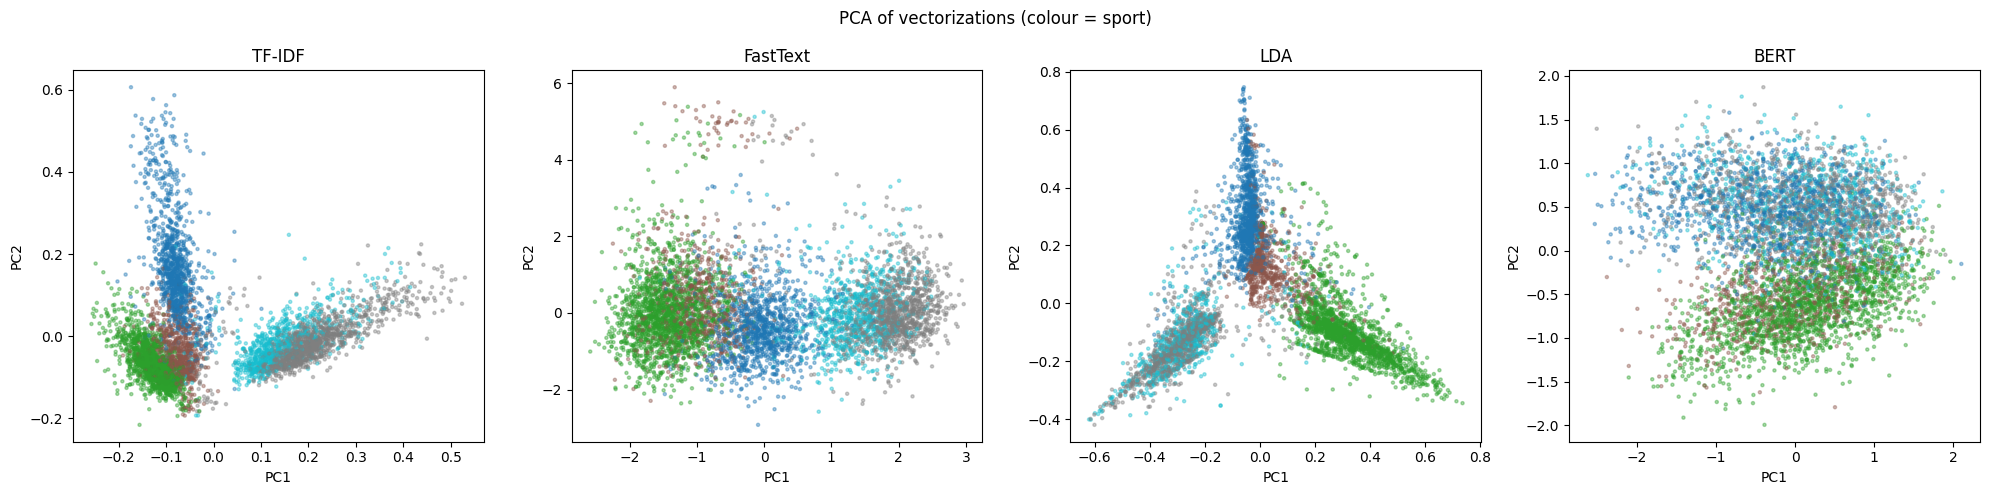

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from pathlib import Path

matrices = {
    "TF-IDF": tfidf_matrix.toarray(),
    "FastText": fasttext_matrix,
    "LDA": lda_matrix,
    "BERT": bert_matrix,
}

sports = df["sport"].values
sport_labels = {s: i for i, s in enumerate(df["sport"].dropna().unique())}
colors = [sport_labels.get(s, -1) for s in sports]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, (name, matrix) in zip(axes, matrices.items()):
    pca = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(matrix)

    scatter = ax.scatter(
        coords[:, 0],
        coords[:, 1],
        c=colors,
        alpha=0.4,
        s=5,
        cmap="tab10"
    )

    ax.set_title(name)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

plt.suptitle("PCA of vectorizations (colour = sport)")
plt.tight_layout()

# Save figure safely inside the project data folder
DATA_DIR.mkdir(parents=True, exist_ok=True)

output_path = DATA_DIR / "pca_comparison.png"
plt.savefig(output_path, dpi=150, bbox_inches="tight")

print("Saved PCA comparison figure to:", output_path)

plt.show()

- **TF - IDF**: shows a clear two - group structure, separating the trails into to main categories along PC1. Thus suggests the trail descriptions naturally split into two main writing styles; probably cycling routes (racebike, touringbicycle, mtb) versus foot-based activities (hike, jogging). However, the sport colours are still mixed within each group, meaning TF-IDF captures broad activity language but struggles to separate similar sports using text alone.
- **FastText**: creates a more scattered and continuous layout with no strong structure. The sports overlap heavily, suggesting that averaging word vectors removes much of the information that separates the sports. FastText captures word meaning well, but it is less effective for distinguishing between trail types.
- **LDA**: gives the clearest result. The star-shaped pattern with distinct arms shows the strongest separation between sports in the figure. Each arm likely represents a main topic linked to a specific activity or terrain type. This makes LDA the easiest method to interpret for content-based recommendation, since trails from the same sport tend to appear together.
- **BERT**: forms two broad overlapping groups with some smaller colour clusters. BERT captures meaning and writing style, so trails with similar descriptions cluster together even if they belong to different sports. this is useful for finding trails with similar themes, but less useful when sport-specific grouping is the main goal.

In [ ]:
print("Final verification")

print("df:", df.shape)
print("Number of raw texts:", len(texts_raw))
print("Number of tokenized texts:", len(tokenized))
print("TF-IDF:", tfidf_matrix.shape)
print("FastText:", fasttext_matrix.shape)
print("LDA:", lda_matrix.shape)
print("BERT:", bert_matrix.shape)

assert len(df) == len(texts_raw)
assert len(df) == len(tokenized)
assert len(df) == tfidf_matrix.shape[0]
assert len(df) == fasttext_matrix.shape[0]
assert len(df) == lda_matrix.shape[0]
assert len(df) == bert_matrix.shape[0]

print("All vectorizations were generated from full_text and dimensions match.")

with open(DATA_DIR / "text_source_used.txt", "r", encoding="utf-8") as f:
    print("Text source:", f.read())

Final verification
df: (5642, 46)
Number of raw texts: 5642
Number of tokenized texts: 5642
TF-IDF: (5642, 5000)
FastText: (5642, 100)
LDA: (5642, 15)
BERT: (5642, 384)
All vectorizations were generated from full_text and dimensions match.
Text source: full_text = description + tips + faqs + region_intro + region_faq
